# Quantum Computing with Qiskit Using UFO Sighting Data

## Objective

This notebook introduces quantum computing using Qiskit. Instead of using random numbers, we use a cleaned UFO sightings dataset to learn how classical data can be represented in quantum circuits.

Topics covered:

- Building quantum circuits
- Understanding qubits
- Quantum gates
- Measurement
- Encoding classical data
- Quantum simulation

In [ ]:
import pandas as pd
import numpy as np
 
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualisation import plot_histogram

In [ ]:
df = pd.read_csv('../data/processed/ufo_clean.csv')

In [5]:
duration = (
    df["length_of_encounter_seconds"]
    .dropna()
    .to_numpy()
)

In [6]:
duration = (
    duration - duration.min()
) / (
    duration.max() - duration.min()
)

In [8]:
duration[:10]

array([2.75971933e-05, 7.35925324e-05, 2.04413508e-07, 2.04413508e-07,
       9.19905761e-06, 3.06634572e-06, 1.83980334e-06, 1.22654135e-05,
       1.83980334e-06, 1.22653216e-06])

In [9]:
qc = QuantumCircuit(1,1)

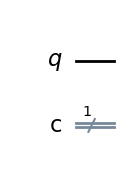

In [10]:
qc.draw('mpl')

A qubit is the quantum equivalent of a classical bit. Unlike a classical bit, which is either 0 or 1, a qubit can exist in a superposition of both states until it is measured.

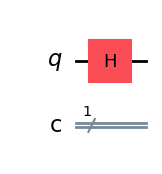

In [11]:
qc.h(0)

qc.draw("mpl")

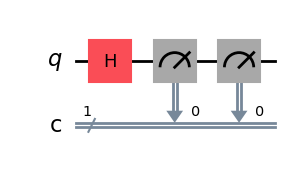

In [13]:
qc.measure(0,0)
qc.draw("mpl")

In [15]:
simulator = AerSimulator()

job = simulator.run(qc, shots=1000)

result = job.result()

counts = result.get_counts()
counts


{'0': 512, '1': 488}

In [16]:
plot_histogram(counts)

NameError: name 'plot_histogram' is not defined

In [ ]:
theta = duration[0]*np.pi

In [ ]:
qc = QuantumCircuit(1,1)

In [ ]:
qc.ry(theta,0)

In [ ]:
qc.measure(0,0)

In [ ]:
job = simulator.run(qc,shots=1000)

counts = job.result().get_counts()

plot_histogram(counts)

In [ ]:
duration[:5]

In [ ]:
results = []

for theta in duration[:5] * np.pi:

    qc = QuantumCircuit(1,1)

    qc.ry(theta,0)

    qc.measure(0,0)

    job = simulator.run(qc,shots=1000)

    counts = job.result().get_counts()

    results.append(counts)

In [ ]:
results

In [ ]:
qc = QuantumCircuit(2,2)

qc.h(0)

qc.cx(0,1)

qc.measure([0,1],[0,1])

qc.draw("mpl")

In [ ]:
job = simulator.run(qc,shots=1000)

counts = job.result().get_counts()

plot_histogram(counts)

## Reflection

In this notebook, I learned the fundamentals of quantum computing using Qiskit. I built and simulated quantum circuits, explored superposition with the Hadamard gate, created an entangled two-qubit Bell state, and encoded normalized UFO encounter durations into quantum states using rotation gates. This demonstrated one practical way classical numerical data can be represented within a quantum circuit, providing a foundation for future quantum machine learning experiments.